In [51]:
import ee
import geemap
import warnings
import os
warnings.filterwarnings('ignore')
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
geemap.ee_initialize()

In [3]:
m = geemap.Map()

In [4]:
accra = gpd.read_file('2020_Parliamentary_Elections_Results_-7351062810980694932.geojson')

In [5]:
accra.head()

,OBJECTID_1,GlobalID,CONSTITUEN,CONS_CODE,ID,Const,District,NAME,TOWNSHIP,Constituen_1,...,Editor,Total_valid_Vote,NPP_2016,NDC_2016,Rejected,Rejecteds,RegisteredVoters,totalvotecast,wininingPRE20,geometry
0,1,905a1fa0-a4d3-4b58-b63b-69a0e42d43fc,AMENFI EAST,WR08,211,AMENFI EAST,Wassa Amenfi East,Amenfi East,Wassa Amenfi East,Amenfi East,...,kwabenadenteh,66169,84413,95283,NaN,5,107305,66174,Amenfi East,"POLYGON ((-1.88306 5.90178, -1.88072 5.90058, ..."
1,2,9918a745-4bfb-43bd-bec2-ec6b1ccdef50,SEGE,GR15,132,SEGE,Dangme East,Sege,Dangme East,Sege,...,kwabenadenteh,32720,38955,37132,NaN,5,39591,32725,Sege,"POLYGON ((0.51200 5.97977, 0.50639 5.96417, 0...."
2,3,e0436033-b1d6-4c80-a5b3-5578435461b5,BINDURI,UE12,166,BINDURI,Bawku Municipal,Binduri,Bawku Municipal,Binduri,...,kwabenadenteh,29578,39688,36991,NaN,5,40846,29583,Binduri,"POLYGON ((-0.35512 11.07163, -0.35465 11.07306..."
3,4,be66c438-3f91-43c9-8c4f-a3a3275e9219,AKIM SWEDRU,ER16,95,AKIM SWEDRU,Birim South,Akim Swedru,Birim South,Akim Swedru,...,kwabenadenteh,15683,18234,17420,NaN,5,20637,15688,Akim Swedru,"POLYGON ((-1.02648 5.91173, -1.02613 5.90926, ..."
4,5,13ae8ecf-c715-4350-a67b-7dcf0b19d834,LAWRA,UW06,187,LAWRA,Lawra District,Lawra,Lawra District,Lawra,...,kwabenadenteh,25282,30108,28325,NaN,5,33716,25287,Lawra,"POLYGON ((-2.71595 10.76042, -2.70175 10.66772..."


In [6]:
accra2 = accra[accra['District'] == 'AMA']

In [8]:
accra2.head()

,OBJECTID_1,GlobalID,CONSTITUEN,CONS_CODE,ID,Const,District,NAME,TOWNSHIP,Constituen_1,...,Editor,Total_valid_Vote,NPP_2016,NDC_2016,Rejected,Rejecteds,RegisteredVoters,totalvotecast,wininingPRE20,geometry
50,51,8619e53b-922a-43e6-95e5-187ad36552f3,OKAIKWEI NORTH,GR10,125,OKAIKWEI NORTH,AMA,Okaikwei North,AMA,Okaikwei North,...,kwabenadenteh,56523,82025,78421,NaN,5,108697,56528,Okaikwei North,"POLYGON ((-0.22313 5.59473, -0.22458 5.59545, ..."
85,86,950fcfbe-035e-414d-9a83-e769625e3538,KORLE KLOTTEY,GR02,120,KORLE KLOTTEY,AMA,Korle Kottey,AMA,Korle Klottey,...,kwabenadenteh,70497,35525,33108,NaN,5,50023,70502,Korle Kottey,"POLYGON ((-0.20866 5.53601, -0.20890 5.53576, ..."
88,89,918cb2f0-1448-4bac-8405-88e1d1f38a82,ABLEKUMA CENTRAL,GR07,112,ABLEKUMA CENTRAL,AMA,Ablekuma Central,AMA,Ablekuma Central,...,kwabenadenteh,93876,86551,82594,NaN,5,112815,93881,Ablekuma Central,"POLYGON ((-0.23275 5.56060, -0.22539 5.55925, ..."
89,90,6d0a5f74-885e-4dc6-97bf-4a950ae263c5,AYAWASO NORTH,GR03,116,AYAWASO NORTH,AMA,Ayawaso North,AMA,Ayawaso North,...,kwabenadenteh,45017,33343,30043,NaN,5,42164,45022,Ayawaso North,"POLYGON ((-0.17501 5.59252, -0.17722 5.59065, ..."
93,94,c6da061f-eb9f-4b49-b608-c811c7289b40,ABLEKUMA SOUTH,GR06,114,ABLEKUMA SOUTH,AMA,Ablekuma South,AMA,Ablekuma South,...,kwabenadenteh,60094,58276,51882,NaN,5,72386,60099,Ablekuma South,"POLYGON ((-0.28026 5.51625, -0.27762 5.51728, ..."


<Axes: >

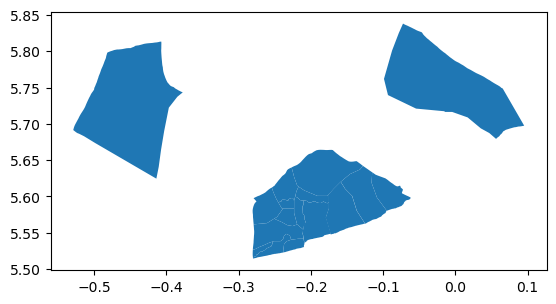

In [9]:
accra2.plot()

In [10]:
accra2['CONSTITUEN'].value_counts()

CONSTITUEN
OKAIKWEI NORTH         1
KORLE KLOTTEY          1
ABLEKUMA WEST          1
ODODODIODIOO           1
OKAIKWEI SOUTH         1
AYAWASO EAST           1
ABLEKUMA NORTH         1
DADEKOTOPON            1
KROWOR                 1
LEDZOKUKU              1
AYAWASO WEST WUOGON    1
DOMEABRA/OBOM          1
KPONE-KATAMANSO        1
AYAWASO CENTRAL        1
ABLEKUMA SOUTH         1
AYAWASO NORTH          1
ABLEKUMA CENTRAL       1
OKAIKWEI CENTRAL       1
Name: count, dtype: int64

In [59]:
# List the districts you want to remove
exclude_districts = ['DOMEABRA/OBOM', 'KPONE-KATAMANSO']

# Filter to keep everything EXCEPT those two
gdf = accra2[~accra2['CONSTITUEN'].isin(exclude_districts)]

<Axes: >

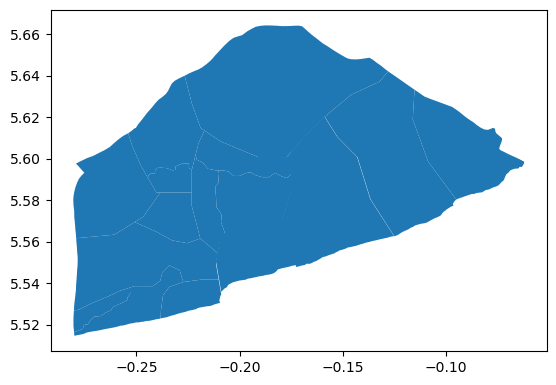

In [60]:
gdf.plot()

In [32]:
gdf.columns

Index(['OBJECTID_1', 'GlobalID', 'CONSTITUEN', 'CONS_CODE', 'ID', 'Const',
       'District', 'NAME', 'TOWNSHIP', 'Constituen_1', 'DIST_2020', 'DIST_POP',
       'DIST_MALE', 'DIST_FEMALE', 'DIST_A18TOTPOP', 'DIST_A18MALEPOP',
       'DIST_A18FEMPOP', 'PERCENT_18', 'FIRST_DISC', 'REGION_12',
       'CONSTITUENCI', 'CONSTITUEN_12', 'NPP_CANDID', 'NPP_VOTES',
       'NDC_CANDID', 'NDC_VOTES', 'WINNING_PARTY_1', 'DISTRICTS',
       'WINNING_CANDIDATE', 'CreationDate', 'Creator', 'EditDate', 'Editor',
       'Total_valid_Vote', 'NPP_2016', 'NDC_2016', 'Rejected', 'Rejecteds',
       'RegisteredVoters', 'totalvotecast', 'wininingPRE20', 'geometry'],
      dtype='object')

In [33]:
gdf1 = gdf[['ID','CONSTITUEN','geometry']]

In [34]:
gdf2 = gdf1.to_crs(epsg=4326)

# 5. Save to GeoJSON
gdf2.to_file("Ga_Mantse.geojson", driver='GeoJSON')

In [35]:
geojson_path  = 'Ga_Mantse.geojson'
roi = geemap.geojson_to_ee(geojson_path)

In [36]:
# Define the study period
start_date = '2025-01-01'
end_date = '2025-12-31'

In [37]:
# 3. MODIS MAIAC (Aerosols: The primary predictor for PM2.5)
collection = ee.ImageCollection("MODIS/061/MCD19A2_GRANULES") \
    .filterDate(start_date, end_date) \
    .select('Optical_Depth_055') # AOD at 550nm

In [38]:
def scale_aod(img):
    scaled_image = img.multiply(0.001)
    return scaled_image.copyProperties(img, ['system :time_start', 'system:time_end'])

In [39]:
scaled_aod = collection.map(scale_aod)

In [40]:
avg = scaled_aod.mean().clip(roi)

In [41]:
# Specify the band name inside the visualization parameters
vis_params = {
    'min': 0.0, 
    'max': 0.5, 
    'palette': ['blue', 'green', 'yellow', 'red']
}

m.addLayer(avg, vis_params, 'Clipped AOD')
m.centerObject(roi, zoom=6)
m

Map(bottom=254246.0, center=[5.591581470973678, -0.1879437636756271], controls=(WidgetControl(options=['positi…

In [42]:
def extract_pixel_timeseries(image):
    # 1. Get the ID as an Earth Engine String
    sys_id = ee.String(image.get('system:index'))
    
    # 2. Check if system:time_start exists; if not, parse from ID (A2025001...)
    # We use ee.Algorithms.If to handle the logic server-side
    date = ee.Date(ee.Algorithms.If(
        image.get('system:time_start'),
        image.get('system:time_start'),
        ee.Date.parse('YYYYDDD', sys_id.slice(9, 16)) # Parses 2025001 format
    ))
    
    date_str = date.format('YYYY-MM-DD')
    
    # 3. Sample the pixels
    pixels = image.sampleRegions(
        collection=roi, 
        scale=1000,
        geometries=True
    )
    
    # 4. Attach the date to every pixel feature
    return pixels.map(lambda f: f.set('date', date_str))

# Apply to your collection
pixel_time_series_fc = scaled_aod.map(extract_pixel_timeseries).flatten()

In [44]:
# 1. Flatten your collection to a single table
pixel_time_series_fc = scaled_aod.map(extract_pixel_timeseries).flatten()

# 2. Add Latitude and Longitude to the CSV columns
# (CSVs don't store geometry, so we turn the point into two columns)
def add_lat_lon(feature):
    coords = feature.geometry().coordinates()
    return feature.set('longitude', coords.get(0)).set('latitude', coords.get(1))

pixel_time_series_final = pixel_time_series_fc.map(add_lat_lon)

# 3. Use the Batch Export System
# We use CSV because it is much lighter and faster than GeoJSON for millions of pixels
task = ee.batch.Export.table.toDrive(
    collection=pixel_time_series_final,
    description='Ghana_AOD_Pixel_TimeSeries_Export',
    folder='GEE_PhD_Data', # The folder in your Google Drive
    fileFormat='CSV',
    selectors=['date', 'Optical_Depth_055', 'CONSTITUEN', 'latitude', 'longitude'] # Specify your columns
)

# 4. Start the task
task.start()

print("The task has started! Google is now processing your request in the background.")
print("This will NOT time out. You can even close your laptop.")

The task has started! Google is now processing your request in the background.
This will NOT time out. You can even close your laptop.


In [45]:
aod = pd.read_csv('Ghana_AOD_Pixel_TimeSeries_Export.csv')

In [46]:
aod.head()

,date,Optical_Depth_055,CONSTITUEN,latitude,longitude
0,2025-01-02,0.549,OKAIKWEI NORTH,5.624805,-0.239026
1,2025-01-02,0.543,OKAIKWEI NORTH,5.624805,-0.229989
2,2025-01-02,0.578,OKAIKWEI NORTH,5.615812,-0.248059
3,2025-01-02,0.553,OKAIKWEI NORTH,5.615812,-0.239022
4,2025-01-02,0.550,OKAIKWEI NORTH,5.615812,-0.229986


In [47]:
aod.tail()

,date,Optical_Depth_055,CONSTITUEN,latitude,longitude
19706,2025-12-364,0.338,ODODODIODIOO,5.534873,-0.220919
19707,2025-12-364,0.352,ODODODIODIOO,5.534873,-0.211883
19708,2025-12-364,0.329,ODODODIODIOO,5.525880,-0.229950
19709,2025-12-364,0.303,OKAIKWEI CENTRAL,5.588832,-0.239011
19710,2025-12-364,0.305,OKAIKWEI CENTRAL,5.588832,-0.229975


<Axes: >

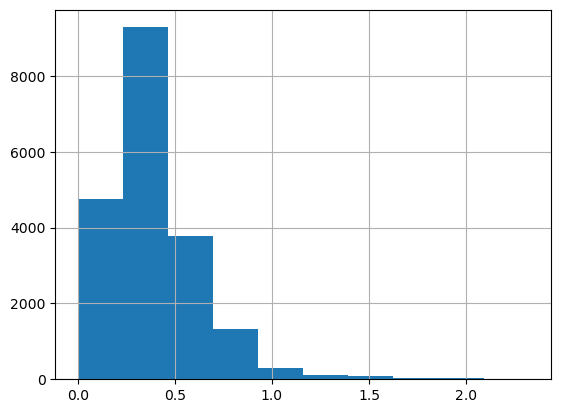

In [48]:
aod['Optical_Depth_055'].hist()

In [49]:
df_grouped = aod.sort_values(by=['date'])

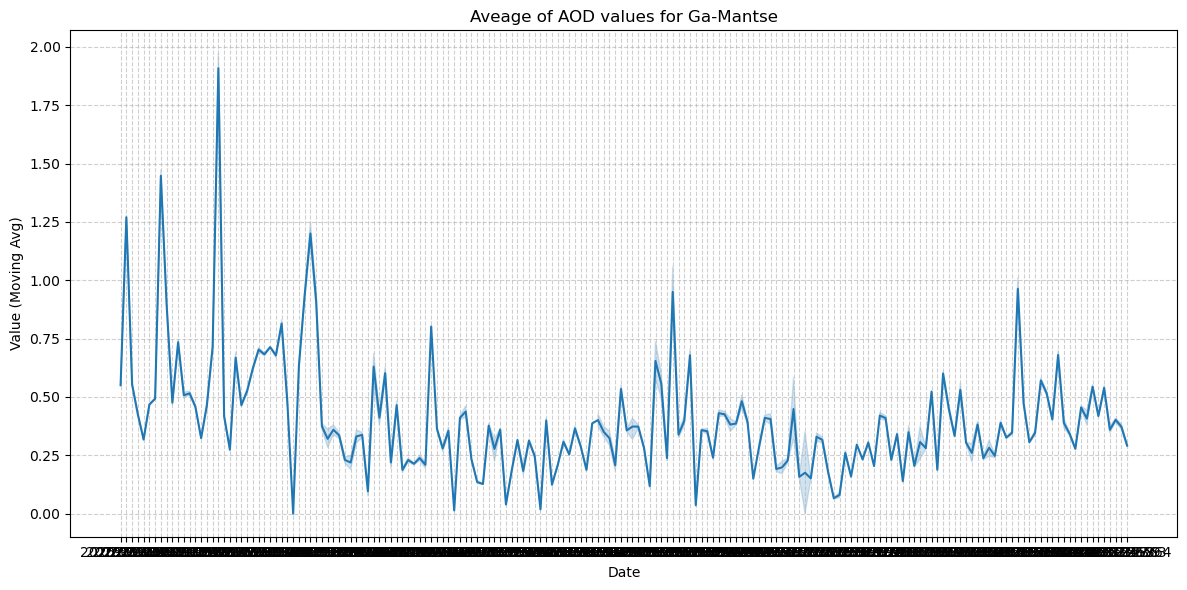

In [53]:
# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='date', y='Optical_Depth_055')

plt.title('Aveage of AOD values for Ga-Mantse')
plt.xlabel('Date')
plt.ylabel('Value (Moving Avg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [56]:
gdf2 = gpd.GeoDataFrame(
    aod, 
    geometry=gpd.points_from_xy(aod.longitude, aod.latitude), 
    crs="EPSG:4326"
)

<Axes: >

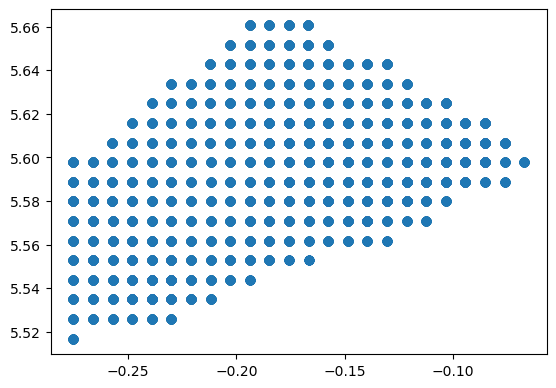

In [57]:
gdf2.plot()

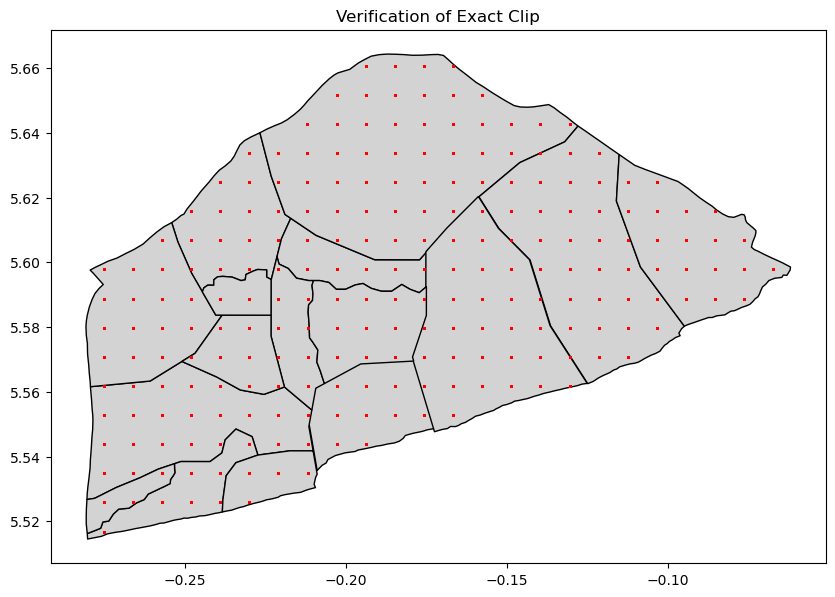

In [61]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf2.plot(ax=ax, color='red', markersize=1)
plt.title("Verification of Exact Clip")
plt.show()

In [62]:
ksi2 = gdf2.to_crs(epsg=4326)

# 5. Save to GeoJSON
ksi2.to_file("GaAOD.geojson", driver='GeoJSON')